
## Learning Objectives

**Why study user-sequences in digital trace data?**

What can we learn from user-sequences that we cannot learn from frequencies or durations alone?

Let's take app use as an example. Have a look at the figure below. Imagine two users who spend the same amount of time on the same apps. Although their overall app use may look identical at the aggregate level, their use patterns tell different stories and potentially lead to different outcomes. For instance, which user do you think is more likely to achieve their learning goals using digital platforms?

You might choose User 1 because this person has longer, uninterrupted blocks of learning 📚, whereas User 2's learning activities are more frequently interrupted by entertainment 🎮 activities. However, if we looked only at the frequency or duration of app use, we would miss this difference. This is where studying user-sequences comes in: by looking at how user activities are sequenced over time, we can go beyond how often or how long people use apps and explore the temporal patterns of their platform activities.


<p align="center">
<img src="./figures/appSequenceExample.png" alt="Two users with the same distribution of app use but different sequences" width="1000">
</p>

This tutorial is a practical companion to our paper, *Exploring Temporal Dynamics in Digital Trace Data: Mining User-Sequences for Communication Research* ([read the paper](https://doi.org/10.1080/19312458.2026.2664873)). Here, I use synthetic data as a quick-start example to explore different sequential features.

By the end of this tutorial, you will be able to:


1. Prepare trace data for sequence analysis.
2. Understand what user-sequences can reveal.
3. Identify and visualize different sequential features.

## Target Audience

This tutorial is aimed at researchers and students interested in digital trace data, with some basic knowledge of Python. No prior experience with sequence analysis is required.

## Setting Up the Environment

The following Python packages are required:



In [ ]:
%pip install -r requirements.txt

## Duration


- Around 2 hours to complete the full tutorial.
- Alternatively, you can focus on specific sections based on the *sequential features* you are interested in.


## Data structure with minimal schema

| Variable | Description |
|----------|-------------|
| Participant ID | Unique id for each participant |
| Timestamp | Time at which the event occurred |
| Event | Any event of interest (e.g., app category) |
| Duration (optional) | Duration of the event |



## Defining a user-sequence

To construct a user-sequence, we first need to define an *event lexicon* (i.e., the set of events we are interested in) and then decide when two events can be considered sequentially connected.

1. What counts as an event?

Depending on the research question, events can be defined at different levels of granularity, take app usage as an example:

- Coarse-grained: Online vs. offline.
- Intermediate: app categories (e.g., social network sites (sns), tools, and video).
- Fine-grained: Individual apps, activity details, or content items.

2. When are two events considered sequentially connected for a participant?

Again, it depends on the study design:

- Across every adjacent record in chronological order.
- Only within the same use *session* (e.g., from screen-on to screen-off).
- Time-based sequence: Only when the time gap between events is within a predefined threshold (e.g., 5 minutes), or within a defined time window (e.g., a calendar day).



## Example: synthetic app-usage data for 40 users


To generate the synthetic data, I used five app categories from Peng & Zhu (2020): `sns` 👥, `video` ▶️, `communication` 💬, `search` 🔎, and `news` 📰.

I predefined four user types (`video_addict`📱, `social_butterfly` 🦋, `information_seeker` 🔍, and `balanced` ⚖️) and generated 10 user-sequences for each type, also allowing for some within-type heterogeneity.

**Datasets**
- `data/synthetic_app_usage_events.csv` — raw event entry data
- `data/synthetic_app_usage_sequences.csv` — sequence-level data


In [2]:
from pathlib import Path
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import product
import scipy.stats
from nltk.util import ngrams
import matplotlib.dates as mdates
from matplotlib.patches import Patch
from rapidfuzz.distance import Levenshtein
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.spatial.distance import squareform

data = Path("./data")
cats = ["sns", "video", "communication", "search", "news"]
events = pd.read_csv(data / "synthetic_app_usage_events.csv")
events["timestamp"] = pd.to_datetime(events["timestamp"], format="mixed").dt.floor("s")
events = events.sort_values(
    ["participant_id", "timestamp", "event_index"]
).reset_index(drop=True)

# from raw events to user-sequences
#sequences=events.sort_values(by="timestamp").groupby(["participant_id"]).app_category.agg(list).reset_index()
sequences = pd.read_csv(data / "synthetic_app_usage_sequences.csv")
sequences["app_category"] = sequences["app_category"].map(ast.literal_eval)
sequences["duration"] = sequences["duration"].map(ast.literal_eval)

print(f"events: {len(events):,} rows | participants: {events['participant_id'].nunique()}")
print(f"sequences: {len(sequences)} participants")
events.head()

events: 15,518 rows | participants: 40
sequences: 40 participants


,participant_id,user_type,event_index,timestamp,app_category,app_name,duration_sec,prev_app_category
0,P01,video_addict,1,2026-07-06 08:56:00,sns,X,160.7,NaN
1,P01,video_addict,2,2026-07-06 09:01:45,video,Netflix,52.8,sns
2,P01,video_addict,3,2026-07-06 09:04:10,news,NewsApp,139.6,video
3,P01,video_addict,4,2026-07-06 09:10:16,video,YouTube,250.3,news
4,P01,video_addict,5,2026-07-06 09:15:26,video,Netflix,74.4,video


In [3]:
print("Sample composition:")
sequences.groupby("user_type").size().rename("n").to_frame().reset_index()

Sample composition:


,user_type,n
0,balanced,10
1,information_seeker,10
2,social_butterfly,10
3,video_addict,10


In [4]:
print("Category counts by user type:")
counts = (
    events.groupby(["user_type", "app_category"])
    .size()
    .unstack("app_category")
)
counts

Category counts by user type:


app_category,communication,news,search,sns,video
user_type,,,,,
balanced,891,771,899,849,781
information_seeker,565,1150,1330,496,289
social_butterfly,1276,427,525,1251,425
video_addict,381,270,471,766,1705


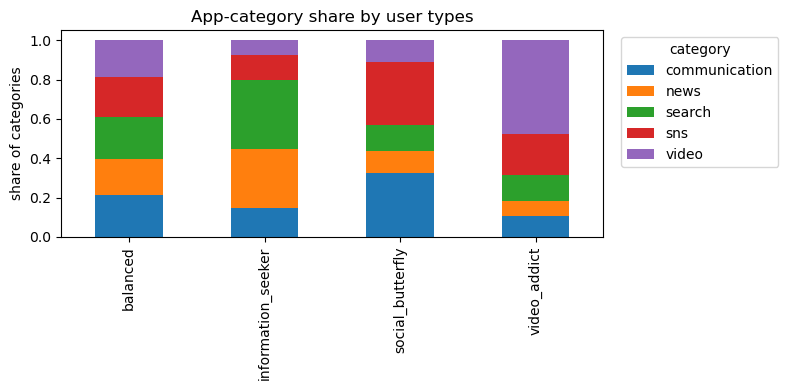

In [5]:
share = counts.div(counts.sum(axis=1), axis=0)
ax = share.plot(kind="bar", stacked=True, figsize=(8, 4))
ax.set_ylabel("share of categories")
ax.set_xlabel("")
ax.legend(title="category", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.set_title("App-category share by user types")
plt.tight_layout()
plt.show()


## Sequential Features

Depending on your research question, you may be interested in different sequential features, including *transitions*, *durations*, *subsequences*, *latent states*, *routines*, *trajectories*, and *sequence clusters*. In this tutorial, I provide simple examples of five features. See the table below for an overview. 


| Sequential feature | Example research question |
|---|---|
| Transitions | How do users transition between different app categories? |
| Durations | How much time do users spend on an app before switching? |
| Subsequences | What are the most frequent subsequences of app use? |
| Trajectories | How do users' app-use patterns unfold over time? |
| Sequence clusters | Which users have similar app-use sequences? |


### 1. Transitions

Transitions show how users move between app categories. Here, we look at consecutive events and calculate how likely users are to transition from one category to another.

#### Things to consider:
- Adjacency: Which events count as consecutive? 
    - In this example, we use each event and its preceding event.
- Normalization: Do we look at the raw counts of transitions or transition probabilities? 
    - Here, we use probabilities.


In [6]:
# transition matrix
def transition_matrix(df, cats):
    """Row-normalized P(to | from) for consecutive events."""
    pairs = df.dropna(subset=["prev_app_category"])
    counts = (
        pairs.groupby(["prev_app_category", "app_category"])
        .size()
        .unstack("app_category")
        .reindex(index=cats, columns=cats)
        .fillna(0)
    )
    return counts.div(counts.sum(axis=1), axis=0).fillna(0)


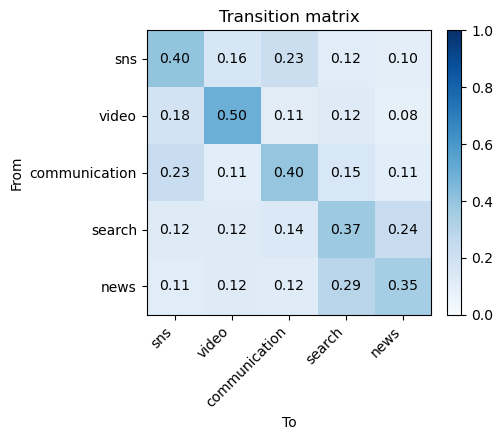

In [7]:
P = transition_matrix(events,cats)
fig, ax = plt.subplots(figsize=(5.5, 4.5))
im = ax.imshow(P.values, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(len(cats)), cats, rotation=45, ha="right")
ax.set_yticks(range(len(cats)), cats)
ax.set_xlabel("To")
ax.set_ylabel("From")
ax.set_title("Transition matrix")
for i in range(len(cats)):
    for j in range(len(cats)):
        ax.text(j, i, f"{P.values[i, j]:.2f}", ha="center", va="center", fontsize=10)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

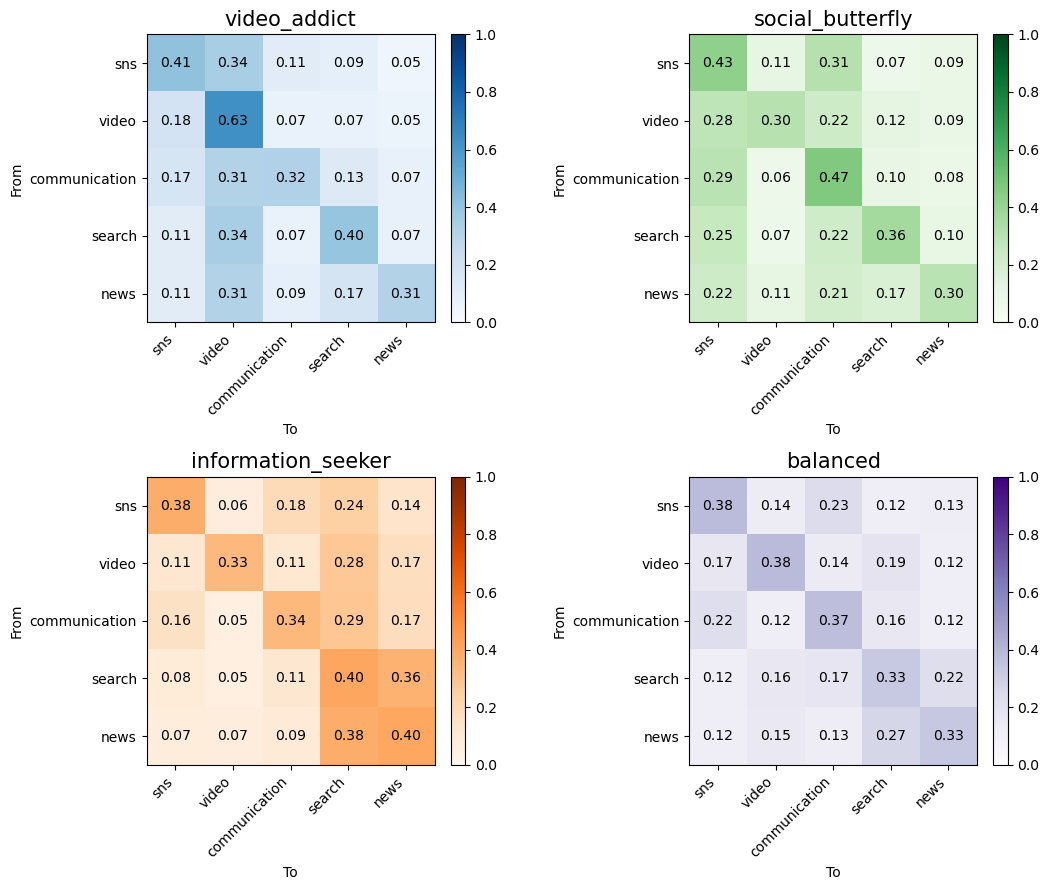

In [8]:
user_types = events.user_type.unique()
cmaps = ["Blues", "Greens", "Oranges", "Purples"]

fig, axes = plt.subplots(2, 2, figsize=(11, 9))

for ax, utype, cmap in zip(axes.flat, user_types, cmaps):
    P = transition_matrix(events[events.user_type == utype], cats)
    im = ax.imshow(P.values, cmap=cmap, vmin=0, vmax=1)
    ax.set_xticks(range(len(cats)), cats, rotation=45, ha="right")
    ax.set_yticks(range(len(cats)), cats)
    ax.set_xlabel("To")
    ax.set_ylabel("From")
    ax.set_title(utype, fontsize=15)
    for i in range(len(cats)):
        for j in range(len(cats)):
            ax.text(j, i, f"{P.values[i, j]:.2f}", ha="center", va="center", fontsize=10)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

for ax in axes.flat[len(user_types):]:
    ax.axis("off")

plt.tight_layout()
plt.show()


#### Example findings
We find that users are most likely to transition within the same app category. For transitions across categories, users are more likely to move from `news` 📰 to `search` 🔎 and from `communication` 💬 to `sns` 👥.
Looking at different user types, we also find that social butterfly users show stronger transitions back and forth between `communication` 💬 and `sns` 👥.


### 2. Durations

Durations show how long users spend on an event before switching to another. Here, we look at the duration of each app-use event.

#### Things to consider:
- Duration: Is duration directly observed (e.g., screen tracking) or inferred from the data (e.g., data download package donations)?
    - Not applicable since we use synthetic data. 
- Continuous use: Do we *merge* consecutive activities as one continuous session? 
    - Here, we only consider the raw duration of each event.  


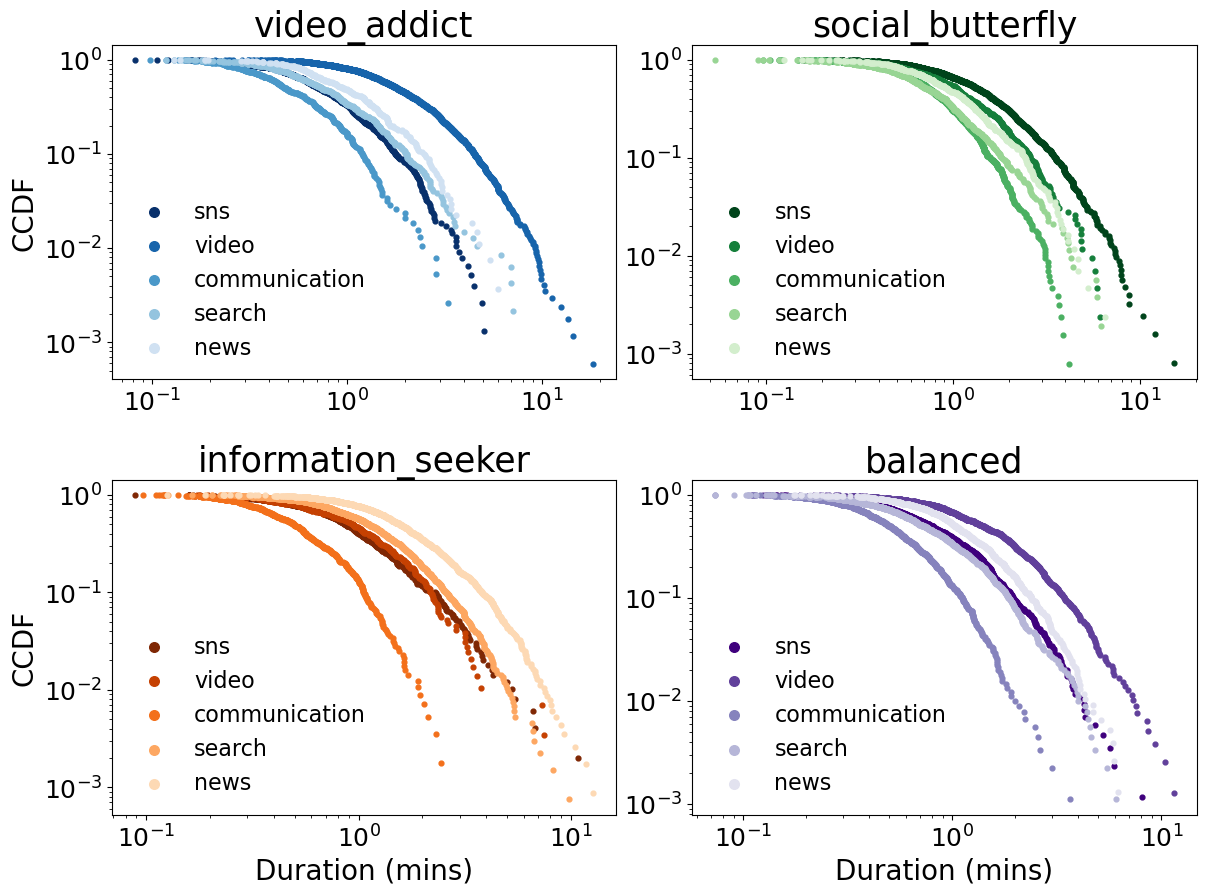

In [9]:
## plot duration sessions: per user type, by category
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
fig.subplots_adjust(hspace=0.3, wspace=0.15)

user_types = events.user_type.unique()
colormaps = ["Blues", "Greens", "Oranges",  "Purples"]

for k, (ax, utype, cmap) in enumerate(zip(axs.flat, user_types, colormaps)):
    df_user = events[events.user_type == utype]
    colors = plt.get_cmap(cmap)(np.linspace(1, 0.2, len(cats))) # avoid white color
    for color, cat in zip(colors, cats):
        durations = df_user.loc[df_user.app_category == cat, "duration_sec"] / 60
        if len(durations) == 0:
            continue
        x = np.sort(durations)
        ccdf = 1.0 - np.arange(len(x)) / len(x)
        ax.scatter(x, ccdf, marker="o", s=12, color=color, label=cat)

    ax.set_xscale("log")
    ax.set_yscale("log")
    if k in [0, 2]:
        ax.set_ylabel("CCDF", fontsize=20)
    if k in [2, 3]:
        ax.set_xlabel("Duration (mins)", fontsize=20)
    ax.tick_params(axis="both", which="major", labelsize=18)
    leg = ax.legend(fontsize=16, loc="lower left", markerscale=2)
    leg.get_frame().set_facecolor("none")
    leg.get_frame().set_linewidth(0.0)
    ax.set_title(utype, fontsize=25)

for ax in axs.flat[len(user_types):]:
    ax.axis("off")

plt.show()


#### Example findings:

The figure shows the duration distributions of five app categories across four user types. The x-axis shows the duration in minutes, and the y-axis shows the complementary cumulative distribution function (CCDF), indicating the proportion of app-use events that are longer than a given duration. We find that `video_addict` users tend to spend longer on `video` ▶️, while `information_seeker` users tend to spend longer on `news` 📰 and `search` 🔎. 

For more advanced analysis, survival analysis can also be used to examine the time until users switch between app categories.



### 3. Subsequences

Subsequences are short segments of user-sequences, such as `news` 📰 → `search` 🔎 → `news` 📰. 

#### Things to consider:
- Subsequence length: How many events should a subsequence contain? 
    - Here, we look at two to four consecutive events.
- Continuous use: When do we consider consecutive activities as one continuous session? 
    - Here, we only consider the raw occurrence of each event.  
- Event-based vs. time-based: Do we focus on the order of events or do we also consider how much time passes between them? 
    - Here, we only focus on event order.
- Temporal window: Do the events need to occur within a certain time window (e.g., 30 minutes or one day)? 
    - Here, we do not impose an additional time constraint.
- Statistical significance: Do we count how often a subsequence occurs or examine whether it occurs more often than expected? 
    - Here, we consider the statistically significant ones.



In [10]:
def get_ngrams(data, n):
    sequences = data.groupby("participant_id")["app_category"].apply(list)
    ngrams_list = sequences.apply(lambda x: list(ngrams(x, n)) if len(x) >= n else [])
    all_ngrams = [item for sublist in ngrams_list for item in sublist]
    return pd.Series(all_ngrams).value_counts()

bigrams = get_ngrams(events, 2)
trigrams = get_ngrams(events, 3)
fourgrams = get_ngrams(events, 4)

### baseline for comparison
label_counts = events['app_category'].value_counts()
total_labels = label_counts.sum()
label_frequencies = label_counts / total_labels


def calculate_expected(ngram_counts, label_frequencies, total_ngrams):
    results = {}
    for ngram, count in ngram_counts.items():
        # Calculate expected frequency as a product of the probabilities
        expected_prob = np.prod([label_frequencies.get(label, 0) for label in ngram])
        expected_freq = expected_prob * total_ngrams

        # Convert count to percentage
        observed_freq=count 
        observed_percentage = (count / total_ngrams) * 100 
        expected_percentage = expected_prob * 100  # convert expected probability to percentage
        std_dev = np.sqrt(expected_prob * (1 - expected_prob) / total_ngrams) * 100

        # Calculate Z-score
        if std_dev > 0:
            z_score = (observed_percentage - expected_percentage) / std_dev
            p_value = scipy.stats.norm.sf(abs(z_score))*2  # two-sided p-value
            # Apply Bonferroni correction
            alpha = 0.001
            num_tests = len(ngram_counts)
            bonferroni_alpha = alpha / num_tests

            if p_value < bonferroni_alpha:
                results[ngram] = {
                    'Observed % (expected %)': "{:.2f}% ({:.2f}%)".format(observed_percentage, expected_percentage),
                    'Observed': "{}".format(observed_freq),
                    'Z-score': z_score,
                    'p-value': "{:.5f}".format(p_value)
                }
    return results

## from bigrams to fourgrams
bigram_results = calculate_expected(bigrams, label_frequencies, bigrams.sum())
trigram_results = calculate_expected(trigrams, label_frequencies, trigrams.sum())
fourgram_results = calculate_expected(fourgrams, label_frequencies, fourgrams.sum())

pd.set_option("display.width", 200)
for name, r in [("bigrams", bigram_results), ("trigrams", trigram_results), ("fourgrams", fourgram_results)]:
    print(name, len(r))
    print(pd.DataFrame.from_dict(r, orient="index").head(7), "\n")
    print()


bigrams 22
                            Observed % (expected %) Observed    Z-score  p-value
video         video                  10.29% (4.25%)     1592  37.198756  0.00000
sns           sns                     8.71% (4.69%)     1348  23.618781  0.00000
communication communication           7.97% (4.02%)     1233  24.953795  0.00000
search        search                  7.76% (4.32%)     1201  21.054927  0.00000
news          news                    5.98% (2.85%)      925  23.417429  0.00000
search        news                    4.91% (3.51%)      760   9.496886  0.00000
news          search                  4.88% (3.51%)      756   9.322087  0.00000 


trigrams 75
                                          Observed % (expected %) Observed    Z-score  p-value
video         video         video                   5.53% (0.88%)      853  61.950401  0.00000
sns           sns           sns                     3.58% (1.02%)      553  31.767662  0.00000
communication communication communication


#### Example findings

Overall, we find that repeated use of the same app category is common. For example, `video` ▶️ → `video` ▶️ and `sns` 👥 → `sns` 👥 are the most frequent bigrams. This pattern also appears in longer subsequences (i.e., trigrams and four-grams), suggesting that users tend to stay within the same app category. 
These patterns occur more often than expected. We also find some frequent subsequences across app categories, such as `search` 🔎 → `news` 📰 and `sns` 👥 → `communication` 💬 → `communication` 💬.


### 4. Trajectories

Trajectories show how app-use patterns unfold over time within a longer time window. 

#### Things to consider:
- Time window: Do we look at the whole sequence or specific periods (e.g., a day, morning, afternoon, or evening)? 
    - Here, we look at daily app-use patterns.
- Duration: Do we look at app use by minute, hour, or longer intervals? 
    - Here, we only use the raw duration recorded in the data.
- Time alignment: Do we compare users based on clock time or time since the start of their activities? 
    - Here, we use clock time.


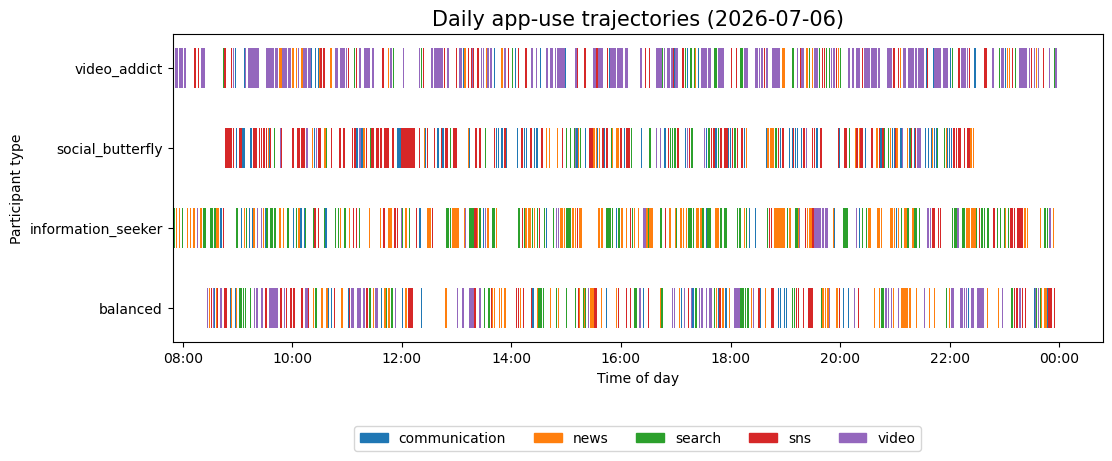

In [11]:
# Select four participants, one from each user type
users = [
    events.loc[events["user_type"] == a, "participant_id"].drop_duplicates().sample(1, random_state=68).iloc[0]
    for a in user_types
]
df = events[events["participant_id"].isin(users)].copy()
# Select one day
day = df["timestamp"].dt.date.min()
df = df[df["timestamp"].dt.date == day].sort_values("timestamp")

# Assign consistent colors to app categories
categories = sorted(events["app_category"].dropna().unique())

# use the same colors as the previous figures
colors = {
    "communication": "tab:blue",
    "news": "tab:orange",
    "search": "tab:green",
    "sns": "tab:red",
    "video": "tab:purple"
}

# Plot one sequence per participant in one day
fig, ax = plt.subplots(figsize=(12, 4))

for i, user in enumerate(users):
    user_data = df[df["participant_id"] == user]

    for _, event in user_data.iterrows():
        ax.barh(
            y=i,
            left=event["timestamp"],
            width=event["duration_sec"] / (24*60*60),
            height=0.5,
            color=colors[event["app_category"]]
        )

ax.set_yticks(range(len(users)))
ax.set_yticklabels(user_types)
ax.invert_yaxis()

ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax.set_xlabel("Time of day")
ax.set_ylabel("Participant type")
ax.set_title(f"Daily app-use trajectories ({day})", fontsize=15)

# Legend
ax.legend(
    handles=[Patch(color=colors[c], label=c) for c in categories],
    loc="upper center",
    bbox_to_anchor=(0.5, -0.25),
    ncol=5
)

plt.show()



#### Example findings

The figure shows how app-use activities unfold throughout the day for four users. We can see some differences in their daily trajectories. For example, `video_addict` users show more `video` ▶️ activities, while `information_seeker` users engage more frequently with `news` 📰 and `search` 🔎. We can also see when these activities occur and how they are distributed throughout the day.


### 5. Sequence Clusters

Sequence clustering helps us identify groups of users with similar app-use sequences. Here, we use *Optimal Matching (OM)* to measure the differences between user-sequences, followed by hierarchical clustering to group similar users.

#### Things to consider:
- Distance measure: How do we compare two user-sequences? Different measures may focus on event order, timing, or duration. 
    - Here, we use a simple version of Optimal Matching.
- Costs: How much does it cost to insert, delete, or substitute an event? 
    - Here, we use insertion/deletion costs of 1 and substitution costs of 2.
- Clustering algorithm: How do we group similar sequences? 
    - Here, we use hierarchical clustering with average linkage.
- Number of clusters: How many groups do we want to identify? 
    - Here, we use four clusters to compare with our predefined user types.



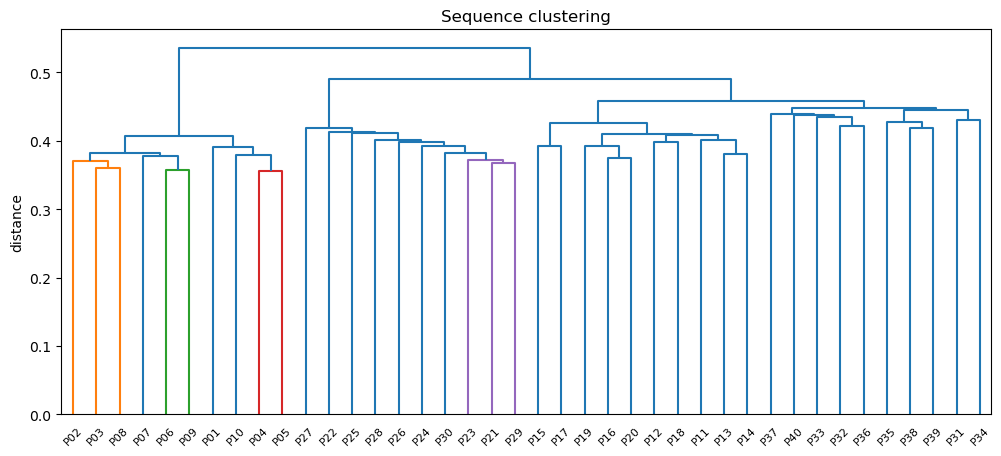

In [12]:

# calculate normalized OM distances
n = len(sequences)
D = np.zeros((n, n))

for i in range(n):
    for j in range(i + 1, n):
        D[i, j] = D[j, i] = Levenshtein.normalized_distance(
        sequences["app_category"].iloc[i],
        sequences["app_category"].iloc[j],
            weights=(1, 1, 2) # insertion 1, delection 1, substitution 2
        )

# Hierarchical clustering
Z = linkage(squareform(D), method="average")

# Plot dendrogram
plt.figure(figsize=(12, 5))
dendrogram(Z, labels=sequences.participant_id.tolist())
plt.title("Sequence clustering")
plt.ylabel("distance")
plt.show()




In [13]:
# Assign four clusters
clusters = fcluster(Z, t=4, criterion="maxclust")

# Compare with predefined user types
results = pd.DataFrame({
    "participant_id": sequences.participant_id,
    "cluster": clusters
})

results = results.merge(
    events[["participant_id", "user_type"]].drop_duplicates(),
    on="participant_id"
)

pd.crosstab(results["cluster"], results["user_type"])

user_type,balanced,information_seeker,social_butterfly,video_addict
cluster,,,,
1,0,0,0,10
2,0,10,0,0
3,0,0,10,0
4,10,0,0,0


#### Example findings

We find that the four identified clusters perfectly match our four predefined user types (`video_addict`📱, `social_butterfly` 🦋, `information_seeker` 🔍, and `balanced` ⚖️).


<!-- End -->


## Conclusion

Now you know how to run some basic sequence analyses with digital trace data! 🎉

### Beyond the Toy Example

When applying these methods to real-world data, there are a few more things to consider:

1. **Data requirements:** In this tutorial, we used synthetic data from 40 users. This is enough to demonstrate the methods and visualize some sequential features, but may be insufficient for reliable participant-level inference or more complex models. For a real-world application, see our [paper](https://doi.org/10.1080/19312458.2026.2664873).
2. **Methodological choices**: This tutorial provides a simple introduction to sequence analysis, and the choices made here are mainly for illustration. When applying these methods to your own data, you should revisit the points raised in the *Things to consider* sections and make decisions based on your research question and data.
3. **Linking user-sequences to other measures:** We can also link user-sequences to other data, such as survey responses, to explore how sequential patterns relate to individual characteristics or outcomes. See Otto et al. (2024) for linkage designs.


### Further Learning

Interested in exploring more sequence analysis methods? Here are some useful tools:

- **[TraMineR](https://traminer.unige.ch/)** (R)
- **[Sequence Graph Transform (SGT)](https://github.com/cran2367/sgt)** (Python)




## References


Peng, T.-Q., & Zhu, J. J. H. (2020). Mobile Phone Use as Sequential Processes: From Discrete Behaviors to Sessions of Behaviors and Trajectories of Sessions. Journal of Computer-Mediated Communication, 25(2), 129–146. https://doi.org/10.1093/jcmc/zmz029

Otto, L. P., Loecherbach, F., & Vliegenthart, R. (2024). Linkage Analysis Revised–Linking Digital Traces and Survey Data. Communication Methods and Measures, 18(2), 186–204. https://doi.org/10.1080/19312458.2023.2257595
